In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import statsmodels.api as sm
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
import prince

import os
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

generato con il codice generate dataset deepseek2


In [45]:
dataset_path = f"../dataset/MC_gill_DEEPSEEK.csv"
df = pd.read_csv(dataset_path)

In [46]:
import pandas as pd

column_mapping = {
    'temporal': 'Temporal',
    'temporal_score': 'Temporal_Score',
    'spatial': 'Spatial',
    'spatial_score': 'Spatial_Score',
    'punctate_pressure': 'Punctate_Pressure',
    'punctate_pressure_score': 'Punctate_Pressure_Score',
    'incisive_pressure': 'Incisive_Pressure',
    'incisive_pressure_score': 'Incisive_Pressure_Score',
    'constrictive_pressure': 'Constrictive_Pressure',
    'constrictive_pressure_score': 'Constrictive_Pressure_Score',
    'traction_pressure': 'Traction_Pressure',
    'traction_pressure_score': 'Traction_Pressure_Score',
    'thermal': 'Thermal',
    'thermal_score': 'Thermal_Score',
    'brightness': 'Brightness',
    'brightness_score': 'Brightness_Score',
    'dullness': 'Dullness',
    'dullness_score': 'Dullness_Score',
    'sensory_miscellaneous': 'Sensory_Misc',
    'sensory_miscellaneous_score': 'Sensory_Misc_Score',
    'tension': 'Tension',
    'tension_score': 'Tension_Score',
    'autonomic': 'Autonomic',
    'autonomic_score': 'Autonomic_Score',
    'fear': 'Fear',
    'fear_score': 'Fear_Score',
    'punishment': 'Punishment',
    'punishment_score': 'Punishment_Score',
    'affective_evaluative_sensory': 'Affective_Eval_Sensory',
    'affective_evaluative_sensory_score': 'Affective_Eval_Sensory_Score',
    'evaluative': 'Evaluative',
    'evaluative_score': 'Evaluative_Score',
    'sensory': 'Sensory',
    'sensory_score': 'Sensory_Score',
    'sensory_2': 'Sensory2',
    'sensory_2_score': 'Sensory2_Score',
    'sensory_3': 'Sensory3',
    'sensory_3_score': 'Sensory3_Score',
    'affective': 'Affective',
    'affective_score': 'Affective_Score',
    'Pain_Time_Pattern': 'Pain_Pattern',
    'current_pain': 'Pain_Now',
    'current_pain_score': 'Pain_Now_Score',
    'worst_pain': 'Pain_Worst',
    'worst_pain_score': 'Pain_Worst_Score',
    'least_pain': 'Pain_Least',
    'least_pain_score': 'Pain_Least_Score',
    'toothache_pain': 'Worst_Toothache',
    'toothache_pain_score': 'Worst_Toothache_Score',
    'headache_pain': 'Worst_Headache',
    'headache_pain_score': 'Worst_Headache_Score',
    'stomachache_pain': 'Worst_Stomachache',
    'stomachache_pain_score': 'Worst_Stomachache_Score',
    'Pain_Type': 'pain_type', 
    'Activity_Interference':'Activity', 'Enjoy_Interference':'Enjoy', 'Mood_Interference':'Mood',
       'Relate_Interference':'Relate', 'Sleep_Interference':'Sleep', 'Walk_Interference':'Walk',
       'Work_Interference': 'Work'
}
       
df.rename(columns=column_mapping, inplace=True)


In [47]:
desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)

# Scoring 1 : tre fasce

In [5]:
df['scoring_1'] = df['PRI'].apply(lambda x: 1 if x < 30 else (2 if x <= 46 else 3))
df['scoring_1'] =df['scoring_1'].astype('category')
df['Sex n']=df['Sex'].apply(lambda x: 0 if x=='F' else 1)

In [6]:
df['scoring_1'].value_counts()

scoring_1
3    341
2     96
1     63
Name: count, dtype: int64

In [7]:
table = pd.crosstab(df['scoring_1'], df['Sex'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print("Chi-quadro:", chi2, "p-value:", p)


group1 = df[df['scoring_1'] == 1]['Age']
group2 = df[df['scoring_1'] == 2]['Age']
group3 = df[df['scoring_1'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
print("T-test 1 vs 2: statistic:", t_stat_12, "p-value:", p_value_12)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
print("T-test 1 vs 3: statistic:", t_stat_13, "p-value:", p_value_13)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)
print("T-test 2 vs 3: statistic:", t_stat_23, "p-value:", p_value_23)

Chi-quadro: 2.295271726893214 p-value: 0.3173862275012925
T-test 1 vs 2: statistic: 0.9566948068676445 p-value: 0.3405647077929259
T-test 1 vs 3: statistic: 1.558100367420146 p-value: 0.12282298979243858
T-test 2 vs 3: statistic: 0.5837141939481972 p-value: 0.5602066249944251


In [8]:
table_sex = pd.crosstab(df['scoring_1'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna

age_stats = df.groupby('scoring_1')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
age_stats['IQR'] = df.groupby('scoring_1')['Age'].quantile(0.75) - df.groupby('scoring_1')['Age'].quantile(0.25)

chi2, p, dof, expected = stats.chi2_contingency(table_sex.iloc[:-1, :-1])  # Rimuoviamo la riga 'All' per il test

group1 = df[df['scoring_1'] == 1]['Age']
group2 = df[df['scoring_1'] == 2]['Age']
group3 = df[df['scoring_1'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)

summary_table = pd.DataFrame({
    'Scoring Group': [1, 2, 3],
    'N (Totale)': age_stats['count'].values,
    'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
    'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
    'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 4)],
    'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 4)]
})

print(summary_table.to_string(index=False))
print(f"Chi-quadro per il sesso tra i gruppi: χ² = {chi2:.2f}, p-value = {p:.3f}")
print(f"T-test età tra 1 e 2: t = {t_stat_12:.2f}, p-value = {p_value_12:.3f}")
print(f"T-test età tra 1 e 3: t = {t_stat_13:.2f}, p-value = {p_value_13:.3f}")
print(f"T-test età tra 2 e 3: t = {t_stat_23:.2f}, p-value = {p_value_23:.3f}")

 Scoring Group  N (Totale) Età Media (SD) Mediana (IQR) Maschi (%) Femmine (%)
             1          63    51.4 (18.1)   51.0 (27.5)      12.1%       13.2%
             2          96    48.7 (16.7)   49.0 (27.5)      21.8%       16.5%
             3         341    47.5 (18.4)   47.0 (31.0)      66.1%       70.4%
Chi-quadro per il sesso tra i gruppi: χ² = 2.30, p-value = 0.317
T-test età tra 1 e 2: t = 0.96, p-value = 0.341
T-test età tra 1 e 3: t = 1.56, p-value = 0.123
T-test età tra 2 e 3: t = 0.58, p-value = 0.560


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_5708/2480631654.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('scoring_1')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_5708/2480631654.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats['IQR'] = df.groupby('scoring_1')['Age'].quantile(0.75) - df.groupby('scoring_1')['Age'].quantile(0.25)


In [98]:
model_dir = "scoring_1 - model , deepseek"
os.makedirs(model_dir, exist_ok=True)

X = df[['Age', 'Sex n','BPM','Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score' ]]

y = df['scoring_1'].astype(int) - 1  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")


Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Sex n', 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Traction_Pressure_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Autonomic_Score', 'Punishment_Score', 'Sensory_Score', 'Sensory2_Score']
Modelli per SVM salvati in scoring_1 - model , deepseek\SVM_all_features.pkl e scoring_1 - model , deepseek\SVM_selected_features.pkl
Accuracy (All features): 0.7
Accuracy (Stepwise features): 0.86
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.00      0.00      0.00        12
           2       0.70      1.00      0.82        70

    accuracy                           0.70       100
   macro avg       0.23      0.33      0.27       100
weighted avg       0.49      0.70      0.58       100

Classification Report (Stepwise features):
               precision 

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Variabili selezionate per XGBoost: ['BPM', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Dullness_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory2_Score']
Modelli per XGBoost salvati in scoring_1 - model , deepseek\XGBoost_all_features.pkl e scoring_1 - model , deepseek\XGBoost_selected_features.pkl
Accuracy (All features): 0.88
Accuracy (Stepwise features): 0.84
Classification Report (All features):
               precision    recall  f1-score   support

           0       1.00      0.39      0.56        18
           1       0.50      0.92      0.65        12
           2       0.99      1.00      0.99        70

    accuracy                           0.88       100
   macro avg       0.83      0.77      0.73       100
weighted avg       0.93      0.88      0.87       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed 

Modelli per Multinomial Logistic Regression salvati in scoring_1 - model , deepseek\Multinomial Logistic Regression_all_features.pkl e scoring_1 - model , deepseek\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.85
Accuracy (Stepwise features): 0.91
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.75      0.33      0.46        18
           1       0.45      0.83      0.59        12
           2       0.99      0.99      0.99        70

    accuracy                           0.85       100
   macro avg       0.73      0.72      0.68       100
weighted avg       0.88      0.85      0.84       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.92      0.61      0.73        18
           1       0.59      0.83      0.69        12
           2       0.99      1.00      0.99        70

    accuracy                       

## Scoring 2, totale delle sezioni

In [9]:
vars_to_map = [
    'liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp', 'weather_changes',
    'massage', 'pressure', 'no_movement', 'movement', 'sleep', 'lying_down',
    'distraction', 'urination', 'bright_lights', 'loud_noises', 'work',
    'intercourse', 'exercise', 'fatigue'
]

for var in vars_to_map:
    df[var] = df[var].apply(lambda x: 1 if x == "increase" else 0)


In [10]:
var=[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score',  'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'exercise',
 'fatigue']
df['Total Pain Score'] = df[var].sum(axis=1)

In [11]:
df['Total Pain Score']

0      77
1      56
2      51
3      52
4      80
       ..
495    78
496    75
497    76
498    76
499    75
Name: Total Pain Score, Length: 500, dtype: int64

Il punteggio massimo raggiungibile da tutte le sezioni è 130, per cui si adotta il seguente scoring: 

- basso dolore se totale < 65 (50%)
- medio dolore se totale > 65 e minore di <91
- dolore alto se totale > 91


In [12]:
df['scoring_2'] = df['Total Pain Score'].apply(lambda x: 'Basso Dolore' if x < 65 else ('Medio Dolore' if x < 91 else 'Alto Dolore'))
#df['scoring_2'] = df['Total Pain Score'].apply(lambda x: 'Basso Dolore' if x < 30 else ('Medio Dolore' if x < 45 else 'Alto Dolore'))
df['scoring_2'] =df['scoring_2'].astype('category')

In [22]:
df['scoring_2_num'] = df['Total Pain Score'].apply(lambda x: 1 if x < 65 else (2 if x < 91 else 3))
#df['scoring_2_num'] = df['Total Pain Score'].apply(lambda x: 1 if x < 45 else (2 if x < 70 else 3))
df['scoring_2_num'] = df['scoring_2_num'].astype('category')

In [23]:
max(df['Total Pain Score'])

82

In [24]:
table_sex = pd.crosstab(df['scoring_2_num'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna
table_sex_percent

Sex,F,M,All
scoring_2_num,,,
1,27.572016,32.295720,30.0
2,38.271605,41.634241,40.0
3,34.156379,26.070039,30.0
All,100.000000,100.000000,100.0


In [25]:
table_sex = pd.crosstab(df['scoring_2_num'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna

# Verifica se la riga con indice 2 esiste, altrimenti la aggiunge
if 3 not in table_sex_percent.index:
    # Crea una riga di zeri con le stesse colonne di table_sex_percent
    zero_row = pd.DataFrame([[0] * len(table_sex_percent.columns)], 
                           columns=table_sex_percent.columns, 
                           index=[3])
    # Inserisci la riga prima di 'All'
    table_sex_percent = pd.concat([table_sex_percent.loc[table_sex_percent.index != 'All'], 
                                  zero_row, 
                                  table_sex_percent.loc[['All']]])

age_stats = df.groupby('scoring_2_num')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
age_stats['IQR'] = df.groupby('scoring_2_num')['Age'].quantile(0.75) - df.groupby('scoring_2_num')['Age'].quantile(0.25)

chi2, p, dof, expected = stats.chi2_contingency(table_sex.iloc[:-1, :-1])  # Rimuoviamo la riga 'All' per il test

group1 = df[df['scoring_2_num'] == 1]['Age']
group2 = df[df['scoring_2_num'] == 2]['Age']
group3 = df[df['scoring_2_num'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)

print(len([f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])]))
print(len([f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])]))
print(len([f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 3)]))
print(len(age_stats['count'].values))

if len([f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])]) == 2:
    summary_table = pd.DataFrame({
        'Scoring Group': [1, 2],
        'N (Totale)': age_stats['count'].values,
        'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
        'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
        'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 3)],
        'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 3)]
    })
else:
    summary_table = pd.DataFrame({
        'Scoring Group': [1, 2, 3],
        'N (Totale)': age_stats['count'].values,
        'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
        'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
        'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 4)],
        'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 4)]
    })

print(summary_table.to_string(index=False))
print(f"Chi-quadro per il sesso tra i gruppi: χ² = {chi2:.2f}, p-value = {p:.3f}")
print(f"T-test età tra 1 e 2: t = {t_stat_12:.2f}, p-value = {p_value_12:.3f}")
print(f"T-test età tra 1 e 3: t = {t_stat_13:.2f}, p-value = {p_value_13:.3f}")
print(f"T-test età tra 2 e 3: t = {t_stat_23:.2f}, p-value = {p_value_23:.3f}")

3
3
2
3
 Scoring Group  N (Totale) Età Media (SD) Mediana (IQR) Maschi (%) Femmine (%)
             1         150    49.7 (17.1)   51.0 (27.0)      32.3%       27.6%
             2         200    48.5 (18.6)   48.5 (32.0)      41.6%       38.3%
             3         150    46.5 (18.3)   43.0 (30.0)      26.1%       34.2%
Chi-quadro per il sesso tra i gruppi: χ² = 4.00, p-value = 0.135
T-test età tra 1 e 2: t = 0.67, p-value = 0.503
T-test età tra 1 e 3: t = 1.61, p-value = 0.109
T-test età tra 2 e 3: t = 1.01, p-value = 0.314


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_5708/1896184551.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('scoring_2_num')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_5708/1896184551.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats['IQR'] = df.groupby('scoring_2_num')['Age'].quantile(0.75) - df.groupby('scoring_2_num')['Age'].quantile(0.25)


In [112]:
model_dir = "scoring_2 - model , deepseek"
os.makedirs(model_dir, exist_ok=True)

X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'exercise',
 'fatigue']]

y = df['scoring_2_num'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")



Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Temporal_Score', 'Spatial_Score', 'Constrictive_Pressure_Score', 'Thermal_Score', 'Punishment_Score', 'Evaluative_Score', 'Sensory_Score', 'cold', 'damp', 'weather_changes', 'massage', 'pressure', 'no_movement', 'movement', 'distraction', 'bright_lights', 'loud_noises', 'work', 'intercourse', 'exercise', 'fatigue']
Modelli per SVM salvati in scoring_2 - model , deepseek\SVM_all_features.pkl e scoring_2 - model , deepseek\SVM_selected_features.pkl
Accuracy (All features): 0.79
Accuracy (Stepwise features): 0.78
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.88      0.86      0.87        49
           1       0.67      0.50      0.57        28
           2       0.74      1.00      0.85        23

    accuracy                           0.79       100
   macro avg       0.76      0.79      0.76       100
weighted avg       0.79      0.79      0.78

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed 

Modelli per Multinomial Logistic Regression salvati in scoring_2 - model , deepseek\Multinomial Logistic Regression_all_features.pkl e scoring_2 - model , deepseek\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.87
Accuracy (Stepwise features): 0.78
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        49
           1       0.89      0.61      0.72        28
           2       0.77      1.00      0.87        23

    accuracy                           0.87       100
   macro avg       0.86      0.86      0.84       100
weighted avg       0.88      0.87      0.86       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.84      0.86      0.85        49
           1       0.64      0.50      0.56        28
           2       0.79      0.96      0.86        23

    accuracy                       

# Scoring 3


In [48]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder
from statsmodels.multivariate.manova import MANOVA
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.extmath import cartesian
from factor_analyzer import FactorAnalyzer
from pingouin import cronbach_alpha

In [49]:

def discretizza_punteggio(punteggi, d):
    return [round((p / d) * 10) for p in punteggi]

df['scoring_3']=discretizza_punteggio(df['PRI'], 78)


In [50]:
data_sel=df[['scoring_3', 'Sex', 'Activity', 'Enjoy',
       'Mood', 'Relate', 'Sleep', 'Walk', 'Work']]


In [51]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

data=data_sel
# I modelli di cut-off testati:
# CP37: [1-3] lieve, [4-7] moderato, [8-10] severo
# CP36: [1-3] lieve, [4-6] moderato, [7-10] severo
# CP47: [1-4] lieve, [5-7] moderato, [8-10] severo
# CP46: [1-4] lieve, [5-6] moderato, [7-10] severo
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data=data_sel.copy()
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ C(Pain_Category) * C(Sex)"
    maov = MANOVA.from_formula(formula, data)
    result = maov.mv_test()
    return result
def compute_partial_eta_squared(data, dependent_var):
    model = ols(f"{dependent_var} ~ C(Pain_Category)", data=data).fit()
    anova_results = anova_lm(model, typ=2)
    ss_effect = anova_results.loc["C(Pain_Category)", "sum_sq"]
    ss_error = anova_results.loc["Residual", "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    return partial_eta_sq

interference_vars = ["Activity","Enjoy",  "Mood", "Sleep", "Work", "Relate", "Walk"]

model_results = {}
for model, cutoffs in cut_off_models.items():
    print(f"Analisi per il modello {model}:")
    
    res = analyze_cutoffs(data_sel.copy(), cutoffs)
    stat_table = res.results['C(Pain_Category)']['stat']
    f_val = stat_table.loc[stat_table.index[0], "F Value"]
    print("Valore F (MANOVA):", f_val)
    
    data_model = data_sel.copy()
    data_model["Pain_Category"] = data_model["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    eta2_values = {}
    for var in interference_vars:
        eta2_values[var] = compute_partial_eta_squared(data_model, var)
    avg_eta2 = np.mean(list(eta2_values.values()))
    print("Partial Eta Squared per variabile:", eta2_values)
    print("Media Partial Eta Squared:", avg_eta2)
    print("-" * 50)
    
    model_results[model] = {"F_value": f_val, "avg_eta2": avg_eta2, "eta2_values": eta2_values}

best_model_by_F = max(model_results, key=lambda m: model_results[m]["F_value"])
best_model_by_eta2 = max(model_results, key=lambda m: model_results[m]["avg_eta2"])

print("Modello migliore in base al Valore F (MANOVA):", best_model_by_F,
      "con F =", model_results[best_model_by_F]["F_value"])
print("Modello migliore in base al Partial Eta Squared medio:", best_model_by_eta2,
      "con Partial Eta Squared =", model_results[best_model_by_eta2]["avg_eta2"])





# Per una valutazione quantitativa, potresti estrarre i valori F per:
# 1) L'effetto principale di C(Pain_Category)
# 2) L'interazione C(Pain_Category):C(Sex)
#
# Se l'F dell'interazione è basso rispetto a quello dell'effetto principale,
# questo suggerisce che la classificazione è robusta rispetto al sesso.
best_model = "CP47"
best_cutoffs = cut_off_models[best_model]
res_cp47 = analyze_cutoffs(data_sel.copy(), best_cutoffs)

stat_table_main = res_cp47.results['C(Pain_Category)']['stat']
stat_table_inter = res_cp47.results['C(Pain_Category):C(Sex)']['stat']

F_main_cp47 = stat_table_main.loc[stat_table_main.index[0], "F Value"]
F_inter_cp47 = stat_table_inter.loc[stat_table_inter.index[0], "F Value"]

print("Modello CP47 - Valore F per l'effetto principale (C(Pain_Category)):", F_main_cp47)
print("Modello CP47 - Valore F per l'interazione (C(Pain_Category):C(Sex)):", F_inter_cp47)

# Se F_inter_cp47 è molto inferiore a F_main_cp47, allora la classificazione (basata su Pain_Worst) è robusta rispetto al sesso.
if F_inter_cp47 < F_main_cp47:
    print("\nL'interazione con il sesso è bassa, indicando che la classificazione è robusta rispetto al sesso.")
else:
    print("\nL'interazione con il sesso è alta; potrebbe esserci una differenza nell'effetto della classificazione tra maschi e femmine.")

Analisi per il modello CP37:
Valore F (MANOVA): 23.947563251032115
Partial Eta Squared per variabile: {'Activity': 0.49850399930622613, 'Enjoy': 0.5444794193714765, 'Mood': 0.570085005511018, 'Sleep': 0.4828071413114321, 'Work': 0.4292841507619137, 'Relate': 0.5186663802939557, 'Walk': 0.4943176097998584}
Media Partial Eta Squared: 0.5054491009079829
--------------------------------------------------
Analisi per il modello CP36:
Valore F (MANOVA): 16.68324466906655
Partial Eta Squared per variabile: {'Activity': 0.44568908924630274, 'Enjoy': 0.4845881663774616, 'Mood': 0.4886295433036039, 'Sleep': 0.4342563950932464, 'Work': 0.4221500433041644, 'Relate': 0.4559458029166319, 'Walk': 0.43092291225906393}
Media Partial Eta Squared: 0.45174027892863927
--------------------------------------------------
Analisi per il modello CP47:
Valore F (MANOVA): 65.05632215786979
Partial Eta Squared per variabile: {'Activity': 0.7089005403498644, 'Enjoy': 0.7863716378856326, 'Mood': 0.7880127885733266,

In [52]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA

data=data_sel
# 1) Definisco i modelli di cut-off
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

# 2) Funzione per assegnare la categoria di dolore
def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

# 3) Funzione che esegue la MANOVA e ricava i valori F
#    - F per l'effetto principale: 'C(Pain_Level)'
#    - F per l'interazione: 'C(Pain_Level):C(Nation)'
#    - Estratti per i test: Pillai, Hotelling, Wilks
def get_f_values_for_model(data, cutoffs):
    df = data.copy()    
    df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))    
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ C(Pain_Level) * C(Sex)"
    maov = MANOVA.from_formula(formula, df)
    mv_res = maov.mv_test()
    
    # Ricava le tabelle per l'effetto principale e per l'interazione
    main_stat = mv_res.results["C(Pain_Level)"]["stat"]
    inter_stat = mv_res.results["C(Pain_Level):C(Sex)"]["stat"]
    
    tests = ["Pillai's trace", "Hotelling-Lawley trace", "Wilks' lambda"]
    

    # main_F = F dell’effetto principale, inter_F = F dell’interazione
    # ratio = main_F / inter_F
    out = {}
    for test_name in tests:
        main_F = main_stat.loc[test_name, "F Value"]
        inter_F = inter_stat.loc[test_name, "F Value"]
        ratio = main_F / inter_F if inter_F != 0 else np.nan
        out[test_name] = (inter_F, main_F, ratio)
    return out

# 4) Ciclo sui modelli di cut-off 
results_all = {}
for model_name, cutoffs in cut_off_models.items():
    fvals = get_f_values_for_model(data, cutoffs)
    results_all[model_name] = fvals

# 5) Tabella per modello 

rows = [
    ("Pillai's trace", "F(Pain by Sex)"),
    ("Pillai's trace", "F(Pain Level)"),
    ("Pillai's trace", "Ratio"),
    ("Hotelling-Lawley trace", "F(Pain by Sex)"),
    ("Hotelling-Lawley trace", "F(Pain Level)"),
    ("Hotelling-Lawley trace", "Ratio"),
    ("Wilks' lambda", "F(Pain by Sex)"),
    ("Wilks' lambda", "F(Pain Level)"),
    ("Wilks' lambda", "Ratio"),
]


table_data = []
for row in rows:
    test_name, label = row
    row_dict = {"Test": f"{test_name} {label}"}
    for model_name in cut_off_models.keys():
        # results_all[model_name][test_name] = (inter_F, main_F, ratio)
        interF, mainF, ratio = results_all[model_name][test_name]
        if "Sex" in label:  # F(Pain by Nation) = inter_F
            val = interF
        elif "Pain Level" in label:  # F(Pain Level) = main_F
            val = mainF
        else:  # Ratio
            val = ratio
        row_dict[model_name] = val
    table_data.append(row_dict)

df_table = pd.DataFrame(table_data)
print("\n--- Tabella stile paper ---")
print(df_table)

print("\n--- Tabella in formato LaTeX ---")
print(df_table.to_latex(index=False, float_format="%.2f"))



--- Tabella stile paper ---
                                    Test       CP37       CP36       CP47  \
0          Pillai's trace F(Pain by Sex)   0.360259   0.884453   1.448991   
1           Pillai's trace F(Pain Level)  20.375855  14.918869  44.342379   
2                   Pillai's trace Ratio  56.558868  16.867911  30.602239   
3  Hotelling-Lawley trace F(Pain by Sex)   0.359011   0.885002   1.464180   
4   Hotelling-Lawley trace F(Pain Level)  27.663551  18.487883  89.521695   
5           Hotelling-Lawley trace Ratio  77.054908  20.890217  61.141184   
6           Wilks' lambda F(Pain by Sex)   0.359542   0.884501   1.456225   
7            Wilks' lambda F(Pain Level)  23.947563  16.683245  65.056322   
8                    Wilks' lambda Ratio  66.605798  18.861761  44.674637   

        CP46  
0   2.180167  
1  29.891198  
2  13.710508  
3   2.181254  
4  45.376658  
5  20.803014  
6   2.180152  
7  37.353798  
8  17.133574  

--- Tabella in formato LaTeX ---
\begin{tabular}{

In [53]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# -------- 1) Definizione dei cut-off e funzioni preesistenti --------

cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data = data.copy()
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate + Sleep + Walk + Work ~ C(Pain_Category) * C(Sex)"
    maov = MANOVA.from_formula(formula, data)
    return maov.mv_test()

def compute_partial_eta_squared(data, dependent_var):
    model = ols(f"{dependent_var} ~ C(Pain_Category)", data=data).fit()
    anova_results = anova_lm(model, typ=2)
    ss_effect = anova_results.loc["C(Pain_Category)", "sum_sq"]
    ss_error = anova_results.loc["Residual", "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    return partial_eta_sq

# Funzioni per Cronbach's alpha
def cronbach_alpha(df_items):
    items = df_items.to_numpy(dtype=float)
    k = items.shape[1]
    var_items = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    var_total = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items.sum() / var_total)
    return alpha

def alpha_if_item_deleted(df_items):
    results = {}
    for col in df_items.columns:
        alpha_del = cronbach_alpha(df_items.drop(columns=[col]))
        results[col] = alpha_del
    return results

# -------- 2) Analisi dei modelli e selezione  --------

interference_vars = ["Activity","Enjoy","Mood","Sleep","Work","Relate","Walk"]

def run_analysis(data):
    model_results = {}
    for model, cutoffs in cut_off_models.items():
        print(f"Analisi per il modello {model}:")
        
        # MANOVA: calcola il valore F (Pillai's trace)
        res = analyze_cutoffs(data, cutoffs)
        stat_table = res.results['C(Pain_Category)']['stat']
        f_val = stat_table.loc[stat_table.index[0], "F Value"]
        print("Valore F (MANOVA):", f_val)
        
        # Partial Eta Squared medio
        data_model = data.copy()
        data_model["Pain_Category"] = data_model["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
        eta2_values = {}
        for var in interference_vars:
            eta2_values[var] = compute_partial_eta_squared(data_model, var)
        avg_eta2 = np.mean(list(eta2_values.values()))
        
        print("Partial Eta Squared per variabile:", eta2_values)
        print("Media Partial Eta Squared:", avg_eta2)
        print("-" * 50)
        
        model_results[model] = {"F_value": f_val, "avg_eta2": avg_eta2, "eta2_values": eta2_values}
    
    best_model_by_F = max(model_results, key=lambda m: model_results[m]["F_value"])
    best_model_by_eta2 = max(model_results, key=lambda m: model_results[m]["avg_eta2"])
    
    print("Modello migliore in base al Valore F (MANOVA):", best_model_by_F,
          "con F =", model_results[best_model_by_F]["F_value"])
    print("Modello migliore in base al Partial Eta Squared medio:", best_model_by_eta2,
          "con Partial Eta Squared =", model_results[best_model_by_eta2]["avg_eta2"])
    
    return best_model_by_F, best_model_by_eta2, model_results

# -------- 3) Calcolo di Cronbach's alpha a ciascun livello (lieve, moderato, severo) --------

def cronbach_table_for_model(data, cutoffs):
    """
    Per ciascun livello di dolore (0=lieve, 1=moderato, 2=severo), 
    calcola:
    - Cronbach's alpha complessivo sulle 7 interferenze
    - Alpha if item deleted per ciascun item
    Ritorna un dizionario con i risultati.
    """
    df = data.copy()
    df["Pain_Category"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    
    results_by_level = {}
    for level in [0, 1, 2]:
        subset = df[df["Pain_Category"] == level]
        if len(subset) == 0:
            continue        
        df_items = subset[interference_vars].dropna()        
        alpha_full = cronbach_alpha(df_items)
        alpha_deleted = alpha_if_item_deleted(df_items)
        
        results_by_level[level] = {
            "N": len(df_items),
            "alpha_full": alpha_full,
            "alpha_deleted": alpha_deleted
        }
    return results_by_level



# 4.1) Esegue l'analisi e individua il modello migliore
best_model_F, best_model_eta, all_results = run_analysis(data)

# 4.2) Cronbach's alpha per CP47
best_model = "CP37"
best_cutoffs = cut_off_models[best_model]
alpha_results = cronbach_table_for_model(data, best_cutoffs)

# 4.3) 
print("\n=== Cronbach's Alpha per CP47 (suddivisione: 1-4 lieve, 5-7 moderato, 8-10 severo) ===")
for level in alpha_results:
    level_name = {0: "Mild (1-4)", 1: "Moderate (5-7)", 2: "Severe (8-10)"}[level]
    info = alpha_results[level]
    print(f"\n*** {level_name} pain level ***")
    print("N =", info["N"])
    print("Interference alpha =", round(info["alpha_full"], 4))
    
    # Alpha if item deleted
    print("Alpha if item deleted:")
    for item, alpha_val in info["alpha_deleted"].items():
        print(f"  {item}: {round(alpha_val, 4)}")



Analisi per il modello CP37:
Valore F (MANOVA): 23.947563251032115
Partial Eta Squared per variabile: {'Activity': 0.49850399930622613, 'Enjoy': 0.5444794193714765, 'Mood': 0.570085005511018, 'Sleep': 0.4828071413114321, 'Work': 0.4292841507619137, 'Relate': 0.5186663802939557, 'Walk': 0.4943176097998584}
Media Partial Eta Squared: 0.5054491009079829
--------------------------------------------------
Analisi per il modello CP36:
Valore F (MANOVA): 16.68324466906655
Partial Eta Squared per variabile: {'Activity': 0.44568908924630274, 'Enjoy': 0.4845881663774616, 'Mood': 0.4886295433036039, 'Sleep': 0.4342563950932464, 'Work': 0.4221500433041644, 'Relate': 0.4559458029166319, 'Walk': 0.43092291225906393}
Media Partial Eta Squared: 0.45174027892863927
--------------------------------------------------
Analisi per il modello CP47:
Valore F (MANOVA): 65.05632215786979
Partial Eta Squared per variabile: {'Activity': 0.7089005403498644, 'Enjoy': 0.7863716378856326, 'Mood': 0.7880127885733266,

In [54]:
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
### ANCHE PER SESSO OLTRE CHE PER PAIN
# --- Cut-off e funzioni di base  ---
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0 = lieve, 1 = moderato, 2 = severo
    return np.nan

def cronbach_alpha(df_items):
    """ Calcola l'alpha di Cronbach su un set di item (colonne). """
    items = df_items.to_numpy(dtype=float)
    k = items.shape[1]
    var_items = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    var_total = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items.sum() / var_total)
    return alpha

def alpha_if_item_deleted(df_items):
    """
    Restituisce un dizionario {nome_item: alpha_senza_item} 
    calcolando alpha di Cronbach escludendo ogni item a turno.
    """
    results = {}
    for col in df_items.columns:
        df_temp = df_items.drop(columns=[col])
        results[col] = cronbach_alpha(df_temp)
    return results

# --- Variabili di interferenza ---
interference_vars = ["Activity","Enjoy","Mood","Sleep","Work","Relate","Walk"]

# --- Funzione per calcolare Cronbach's alpha per (Pain Category, Sex) ---
def cronbach_table_for_model_by_sex(data, cutoffs):
    """
    Per ciascuna combinazione di Pain_Category (0,1,2) e Sex (ad es. M,F),
    calcola:
      - N (numero di osservazioni)
      - alpha_full (cronbach alpha su tutti gli item)
      - alpha_if_item_deleted (cronbach alpha escludendo ogni item)
    Ritorna un dizionario annidato:
      results[sex][pain_category] = { 'N': ..., 'alpha_full': ..., 'alpha_deleted': {...} }
    """
    df = data.copy()
    df["Pain_Category"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    
    sexes = df["Sex"].dropna().unique()  
    
    results = {}
    for s in sexes:
        results[s] = {}
        for level in [0, 1, 2]:
            subset = df[(df["Pain_Category"] == level) & (df["Sex"] == s)]
            if len(subset) == 0:
                continue            
            df_items = subset[interference_vars].dropna()
            
            alpha_full = cronbach_alpha(df_items)
            alpha_del = alpha_if_item_deleted(df_items)
            
            results[s][level] = {
                "N": len(df_items),
                "alpha_full": alpha_full,
                "alpha_deleted": alpha_del
            }
    
    return results

def main():
    best_model = "CP37"
    best_cutoffs = cut_off_models[best_model]
    alpha_results_sex = cronbach_table_for_model_by_sex(data, best_cutoffs)
    print("\n=== Cronbach's Alpha per CP47 diviso per Sesso e Livello di Dolore ===")
    for s in alpha_results_sex:
        print(f"\n=== Sesso: {s} ===")
        for level in sorted(alpha_results_sex[s].keys()):
            # 0 = mild, 1 = moderate, 2 = severe
            level_name = {0: "Mild (1-4)", 1: "Moderate (5-7)", 2: "Severe (8-10)"}[level]
            info = alpha_results_sex[s][level]
            print(f"\n--- {level_name} ---")
            print("N =", info["N"])
            print("Interference alpha =", round(info["alpha_full"], 4))
            print("Alpha if item deleted:")
            for item, alpha_val in info["alpha_deleted"].items():
                print(f"  {item}: {round(alpha_val, 4)}")
main()


=== Cronbach's Alpha per CP47 diviso per Sesso e Livello di Dolore ===

=== Sesso: M ===

--- Mild (1-4) ---
N = 4
Interference alpha = 0.8985
Alpha if item deleted:
  Activity: 0.8749
  Enjoy: 0.9111
  Mood: 0.8514
  Sleep: 0.8978
  Work: 0.9035
  Relate: 0.8455
  Walk: 0.878

--- Moderate (5-7) ---
N = 186
Interference alpha = 0.9672
Alpha if item deleted:
  Activity: 0.9633
  Enjoy: 0.9601
  Mood: 0.9604
  Sleep: 0.9621
  Work: 0.9647
  Relate: 0.9597
  Walk: 0.9632

--- Severe (8-10) ---
N = 67
Interference alpha = 0.8251
Alpha if item deleted:
  Activity: 0.8053
  Enjoy: 0.8231
  Mood: 0.7806
  Sleep: 0.7796
  Work: 0.8144
  Relate: 0.8022
  Walk: 0.8023

=== Sesso: F ===

--- Mild (1-4) ---
N = 5
Interference alpha = 0.8587
Alpha if item deleted:
  Activity: 0.8565
  Enjoy: 0.8818
  Mood: 0.8283
  Sleep: 0.8116
  Work: 0.8016
  Relate: 0.7723
  Walk: 0.8805

--- Moderate (5-7) ---
N = 155
Interference alpha = 0.9605
Alpha if item deleted:
  Activity: 0.9563
  Enjoy: 0.9534
  Moo

In [55]:
variables = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]


# for var in variables:
#     df[var + "_2"] = 10 - df[var]
# for var in variables:
#      df[var] = 10 - df[var]

In [56]:
df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cut_off_models["CP47"]))

In [57]:
df.Pain_Level.value_counts()

Pain_Level
1    200
2    150
0    150
Name: count, dtype: int64

In [58]:
cut_off_models["CP47"]

[(1, 4), (5, 7), (8, 10)]

In [59]:
variables = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]

def categorize_pain(x, cutoffs):
    if x <=4:
        return "Mild"
    elif x <= 7:
        return "Moderate"
    else:
        return "Severe"
df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))

grouped = df.groupby(["Pain_Level", "Sex"])[variables].mean().reset_index()

print(grouped)


  Pain_Level Sex   Activity     Enjoy      Mood     Sleep      Work    Relate  \
0       Mild   F   5.268657  4.179104  4.313433  4.820896  4.955224  4.208955   
1       Mild   M   4.686747  4.204819  4.277108  4.698795  4.638554  4.156627   
2   Moderate   F   7.397849  7.096774  6.913978  7.720430  8.032258  7.129032   
3   Moderate   M   7.700935  7.130841  7.140187  7.794393  8.056075  7.214953   
4     Severe   F  10.000000  9.710843  9.722892  9.951807  9.987952  9.759036   
5     Severe   M   9.910448  9.641791  9.731343  9.880597  9.955224  9.611940   

       Walk  
0  4.701493  
1  4.493976  
2  7.344086  
3  7.392523  
4  9.746988  
5  9.686567  


5.268656716417911
7.397849462365591
10.0
4.686746987951807
7.700934579439252
9.91044776119403
4.17910447761194
7.096774193548387
9.710843373493976
4.204819277108434
7.130841121495327
9.64179104477612
4.313432835820896
6.913978494623656
9.72289156626506
4.27710843373494
7.140186915887851
9.73134328358209
4.82089552238806
7.720430107526882
9.951807228915662
4.698795180722891
7.794392523364486
9.880597014925373
4.955223880597015
8.03225806451613
9.987951807228916
4.63855421686747
8.05607476635514
9.955223880597014
4.208955223880597
7.129032258064516
9.759036144578314
4.156626506024097
7.214953271028038
9.611940298507463
4.701492537313433
7.344086021505376
9.74698795180723
4.493975903614458
7.392523364485982
9.686567164179104


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_5708/1977483161.py:68: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


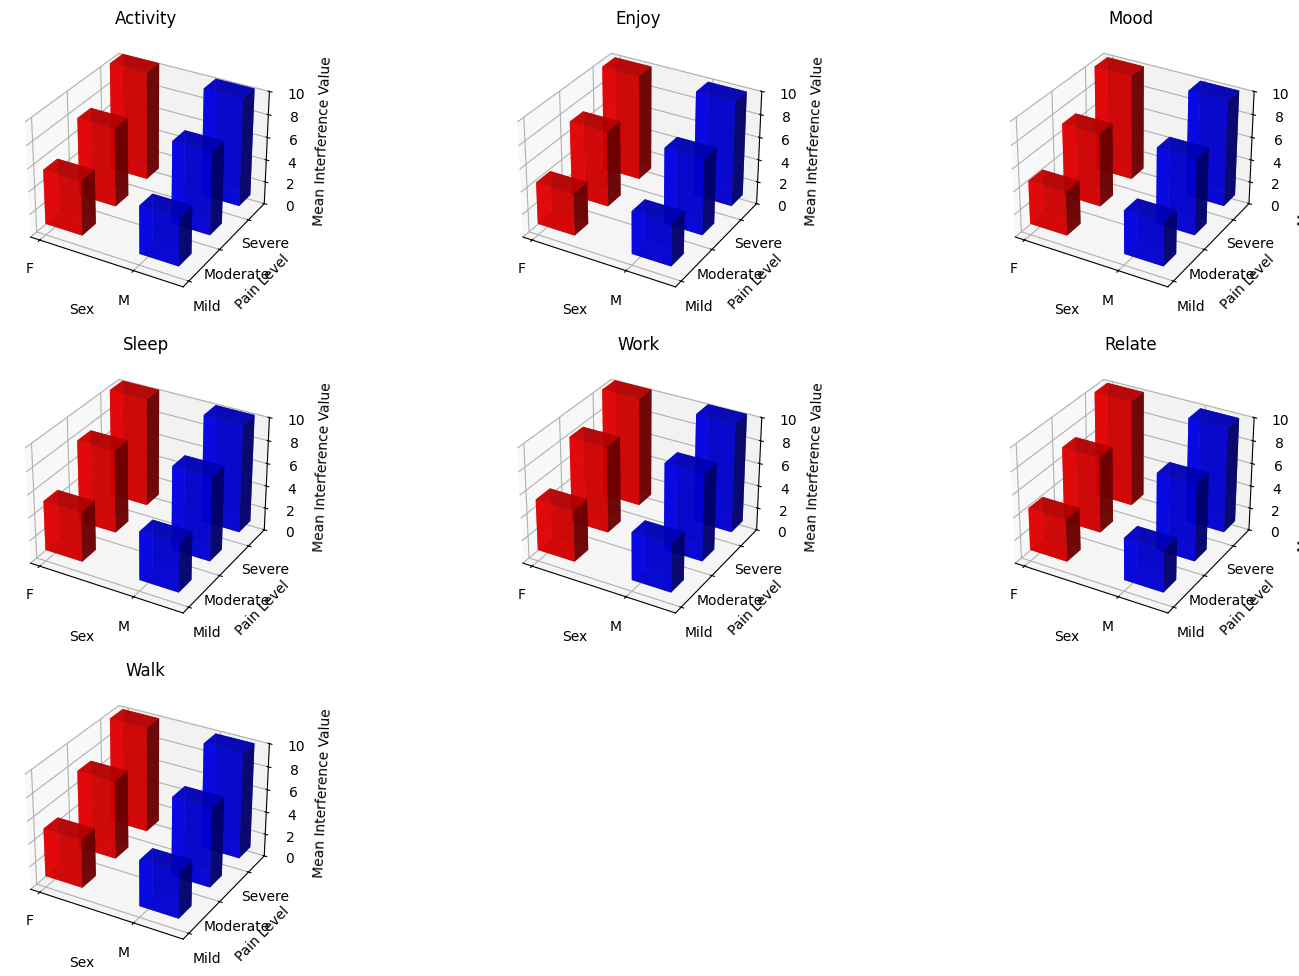

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  

def plot_3d_interference_by_sex(data, items, sex_col='Sex', pain_col='Pain_Level'):
    """
    Crea 7 subplot 3D (uno per ogni item in 'items') in cui:
      - Asse X = sesso (M, F)
      - Asse Y = livello di dolore (Mild, Moderate, Severe)
      - Asse Z = valore medio dell'item di interferenza (da 1 a 10).
    """
    pain_labels = ['Mild', 'Moderate','Severe' ]

    sexes = sorted(data[sex_col].dropna().unique())
    
#    print("Unique values in Sex column:", data[sex_col].unique())
#    print("Unique values in Pain_Level column:", data[pain_col].unique())    
    fig = plt.figure(figsize=(18, 12))
    
    for i, item in enumerate(items):
        ax = fig.add_subplot(3, 3, i + 1, projection='3d')
        
        group_means = data.groupby([sex_col, pain_col])[item].mean().reset_index()
#        print(group_means)
        
        dx = 0.4
        dy = 0.4
        base_value = 1 
        offset = 0.5  
        
        for s_i, sex_val in enumerate(sexes):
            for p_i, pain_level in enumerate(pain_labels):  
                
                
                subset = group_means[
                    (group_means[sex_col] == sex_val) & 
                    (group_means[pain_col] == pain_level)
                ]
                
                
                
                if len(subset) == 0:
                    mean_val = base_value  
                else:
                    mean_val = subset[item].values[0]
                print(mean_val)
                x = s_i
                y = p_i
                color = 'blue' if sex_val == 'M' else 'red'
                
                dz = mean_val - base_value + offset
                
                if mean_val < base_value:
                    dz = offset  
                
                ax.bar3d(x, y, base_value, dx, dy, dz, color=color, alpha=0.8)
        
        ax.set_zlim(0, 10)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(sexes)
        ax.set_yticks(range(len(pain_labels)))
        ax.set_yticklabels(pain_labels)
        ax.set_xlabel('Sex')
        ax.set_ylabel('Pain Level')
        ax.set_zlabel('Mean Interference Value')
        ax.set_title(f'{item}')

    plt.tight_layout()
    plt.show()
    
items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]
plot_3d_interference_by_sex(df, items, sex_col='Sex', pain_col='Pain_Level')


Grafico salvato come: grouped_bar_1row_deepseek.pdf


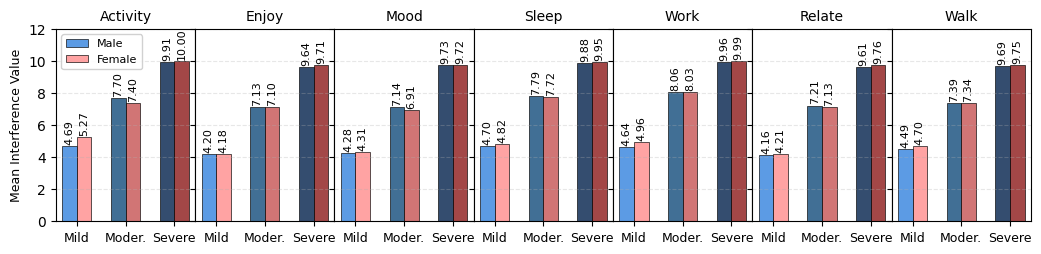

In [63]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_bar_interference_by_sex(data, items, sex_col='Sex', pain_col='Pain_Level', 
                                         save_path='grouped_bar_plot.pdf'):
    pain_labels = ['Mild', 'Moderate', 'Severe']
    
    colors = {
        'M': {
            'Mild': '#4A90E2',
            'Moderate': '#2C5F8A',
            'Severe': '#1E3A5F'
        },
        'F': {
            'Mild': '#FF9999',
            'Moderate': '#CC6666',
            'Severe': '#993333'
        }
    }
    
    fig, axes = plt.subplots(1, 7, figsize=(13, 2.5), sharey=True)
    plt.subplots_adjust(wspace=0,hspace=0, left=0.05, right=0.8)
    
    if len(items) == 1:
        axes = [axes]
    
    # Barre più compatte
    total_width = 0.6
    bar_width = total_width / 2
    offset = bar_width / 2
    
    positions = {
        'M': -offset,
        'F': +offset
    }
    
    for idx, (ax, item) in enumerate(zip(axes, items)):
        group_means = data.groupby([sex_col, pain_col])[item].mean().reset_index()
        
        x = np.arange(len(pain_labels))
        
        means = {}
        for sex in ['M', 'F']:
            for pain in pain_labels:
                val = group_means[(group_means[sex_col] == sex) & 
                                 (group_means[pain_col] == pain)][item].values
                means[f'{sex}_{pain}'] = val[0] if len(val) > 0 else 0
        
        for i, pain in enumerate(pain_labels):
            for sex in ['M', 'F']:
                val = means[f'{sex}_{pain}']
                if val > 0:
                    x_pos = x[i] + positions[sex]
                    
                    ax.bar(x_pos, val, bar_width,
                           color=colors[sex][pain],
                           edgecolor='black', linewidth=0.5,
                           alpha=0.9,
                           label=('Male' if sex == 'M' else 'Female') if i == 0 else "")
                    
                    # Testo centrato sulla barra
                    ax.text(x_pos, val + 0.1,
                            f'{val:.2f}',
                            ha='center', va='bottom', fontsize=8, rotation=90)
        
        ax.set_xticks(x)
        ax.set_xticklabels(['Mild', 'Moder.', 'Severe'], fontsize=9)
        ax.set_ylim(0, 12)
        
        # Y label solo nel primo subplot
        if idx == 0:
            ax.set_ylabel('Mean Interference Value', fontsize=9)
        else:
            ax.set_ylabel('')
        
        ax.set_title(f'{item}', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    
    #fig.suptitle('Interference by Sex and Pain Level', fontsize=14, y=1.02, fontweight='bold')
    
    # Subplot più vicini
    plt.subplots_adjust(wspace=0)
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Grafico salvato come: {save_path}")
    
    plt.show()



# UTILIZZO
items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]

plot_grouped_bar_interference_by_sex(df, items, sex_col='Sex', pain_col='Pain_Level', 
                                     save_path='grouped_bar_1row_deepseek.pdf')

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def build_contingency_table(df, cat_vars, target='Pain_Level', p_threshold=0.11):
    """
    Costruisce una tabella riepilogativa con distribuzione e p-value (chi-quadro)
    per le variabili categoriali (o trattate come tali).
    
    Parametri:
    -----------
    df : pd.DataFrame
        Il DataFrame con i dati
    cat_vars : list of str
        Lista delle variabili categoriali da testare (senza "score")
    target : str
        Nome della variabile categoriale di riferimento (es. 'Pain_Level')
        con valori 0,1,2 (Mild, Moderate, Severe)
    p_threshold : float
        Soglia p-value per includere la variabile nella tabella finale.
        
    Ritorna:
    --------
    results_df : pd.DataFrame
        Tabella con righe corrispondenti alle categorie di ciascuna variabile
        e colonne con conteggi+percentuali per Pain_Level + p-value finale.
    """
    level_counts = df[target].value_counts(dropna=True)
    levels_order = [0, 1, 2]
    
    results_rows = []

    for var in cat_vars:
        ct = pd.crosstab(df[var], df[target])
        
        for lvl in levels_order:
            if lvl not in ct.columns:
                ct[lvl] = 0
        ct = ct[levels_order]
        
        chi2, p_val, dof, expected = stats.chi2_contingency(ct)
        
        if (p_val < p_threshold) or (var in ['Sex']):
            categories = ct.index.tolist()
            for i, cat in enumerate(categories):
                row_data = {}
                row_data['Variable'] = var if i == 0 else ""
                row_data['Category'] = str(cat)
                
                for lvl in levels_order:
                    count_val = ct.loc[cat, lvl]
                    total_lvl = level_counts.get(lvl, 0)
                    if total_lvl > 0:
                        perc = count_val * 100.0 / total_lvl
                    else:
                        perc = 0.0
                    row_data[f'Level_{lvl}'] = f"{count_val} ({perc:.1f}%)"
                
                if i == len(categories) - 1:
                    row_data['p-value'] = f"{p_val:.4f}"
                else:
                    row_data['p-value'] = ""
                
                results_rows.append(row_data)
    
    results_df = pd.DataFrame(results_rows)

    mild_n = level_counts.get(0, 0)
    mod_n = level_counts.get(1, 0)
    sev_n = level_counts.get(2, 0)

    results_df.rename(columns={
        'Level_0': f"Mild (n={mild_n})",
        'Level_1': f"Moderate (n={mod_n})",
        'Level_2': f"Severe (n={sev_n})"
    }, inplace=True)

    return results_df


all_cols = df.columns.tolist()

cat_vars = [c for c in all_cols if "score" not in c.lower()]

results_df = build_contingency_table(df, cat_vars, target='Pain_Level', p_threshold=0.11)
print(results_df)


        Variable   Category  Mild (n=144) Moderate (n=157) Severe (n=197)  \
0            Sex          F    74 (51.4%)       68 (43.3%)     96 (48.7%)   
1                         M    70 (48.6%)       89 (56.7%)    101 (51.3%)   
2   Sensory_Misc    rasping    40 (27.8%)       30 (19.1%)     52 (26.4%)   
3                 splitting    31 (21.5%)       42 (26.8%)     62 (31.5%)   
4                      taut    40 (27.8%)       37 (23.6%)     42 (21.3%)   
..           ...        ...           ...              ...            ...   
82                        8      0 (0.0%)         0 (0.0%)    109 (55.3%)   
83                        9      0 (0.0%)         0 (0.0%)       5 (2.5%)   
84    Pain_Level          0  144 (100.0%)         0 (0.0%)       0 (0.0%)   
85                        1      0 (0.0%)     157 (100.0%)       0 (0.0%)   
86                        2      0 (0.0%)         0 (0.0%)   197 (100.0%)   

   p-value  
0           
1   0.3536  
2           
3           
4         

In [ ]:
latex_code = results_df.to_latex(index=False)
print(latex_code)

\begin{tabular}{llllll}
\toprule
Variable & Category & Mild (n=144) & Moderate (n=157) & Severe (n=197) & p-value \\
\midrule
Sex & F & 74 (51.4%) & 68 (43.3%) & 96 (48.7%) &  \\
 & M & 70 (48.6%) & 89 (56.7%) & 101 (51.3%) & 0.3536 \\
Sensory_Misc & rasping & 40 (27.8%) & 30 (19.1%) & 52 (26.4%) &  \\
 & splitting & 31 (21.5%) & 42 (26.8%) & 62 (31.5%) &  \\
 & taut & 40 (27.8%) & 37 (23.6%) & 42 (21.3%) &  \\
 & tender & 33 (22.9%) & 48 (30.6%) & 41 (20.8%) & 0.0916 \\
heat & 0 & 67 (46.5%) & 66 (42.0%) & 115 (58.4%) &  \\
 & 1 & 77 (53.5%) & 91 (58.0%) & 82 (41.6%) & 0.0061 \\
Tipo_dolore & acute & 144 (100.0%) & 157 (100.0%) & 31 (15.7%) &  \\
 & chronic & 0 (0.0%) & 0 (0.0%) & 166 (84.3%) & 0.0000 \\
PRI & 20 & 93 (64.6%) & 0 (0.0%) & 0 (0.0%) &  \\
 & 21 & 5 (3.5%) & 0 (0.0%) & 0 (0.0%) &  \\
 & 22 & 6 (4.2%) & 0 (0.0%) & 0 (0.0%) &  \\
 & 23 & 6 (4.2%) & 0 (0.0%) & 0 (0.0%) &  \\
 & 24 & 4 (2.8%) & 0 (0.0%) & 0 (0.0%) &  \\
 & 25 & 8 (5.6%) & 0 (0.0%) & 0 (0.0%) &  \\
 & 26 & 10

In [ ]:
pain_level_map = {
    "Mild": 0,
    "Moderate": 1,
    "Severe": 2
}

df["Pain_Level_Coded"] = df["Pain_Level"].map(pain_level_map)


In [145]:
df.Pain_Level_Coded.value_counts()

Pain_Level_Coded
1    200
0    150
2    150
Name: count, dtype: int64

In [ ]:

model_dir = "scoring_3 - model , deepseek"
os.makedirs(model_dir, exist_ok=True)

X = df[[ 'Temporal_Score','Evaluative_Score', 'Sensory_Score', 'Affective_Score']]

y = df['Pain_Level_Coded'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")



Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Temporal_Score', 'Sensory_Score']
Modelli per SVM salvati in scoring_3 - model , deepseek\SVM_all_features.pkl e scoring_3 - model , deepseek\SVM_selected_features.pkl
Accuracy (All features): 0.99
Accuracy (Stepwise features): 0.96
Classification Report (All features):
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.98      1.00      0.99        40
           2       1.00      1.00      1.00        31

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       1.00      0.86      0.93        29
           1       0.91      1.00      0.95        40
           2       1.00      1.00      1.00        31

    accur

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: Futur

Modelli XGBoost caricati correttamente da scoring_3 - model , deepseek\XGBoost_all_features.pkl e scoring_3 - model , deepseek\XGBoost_selected_features.pkl
Modelli Bagging caricati correttamente da scoring_3 - model , deepseek\Bagging_all_features.pkl e scoring_3 - model , deepseek\Bagging_selected_features.pkl
Modelli CART caricati correttamente da scoring_3 - model , deepseek\CART_all_features.pkl e scoring_3 - model , deepseek\CART_selected_features.pkl
Modelli Random Forest caricati correttamente da scoring_3 - model , deepseek\Random Forest_all_features.pkl e scoring_3 - model , deepseek\Random Forest_selected_features.pkl
Modelli Naïve Bayes caricati correttamente da scoring_3 - model , deepseek\Naïve Bayes_all_features.pkl e scoring_3 - model , deepseek\Naïve Bayes_selected_features.pkl
Modelli Multinomial Logistic Regression caricati correttamente da scoring_3 - model , deepseek\Multinomial Logistic Regression_all_features.pkl e scoring_3 - model , deepseek\Multinomial Logisti

# Scoring 4, word-based

In [150]:
df.pain_type.value_counts()

pain_type
neuropathic    378
nociceptive    122
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

descriptor_columns = ['Temporal',
        'Spatial', 'Punctate_Pressure',
       'Incisive_Pressure',
        'Constrictive_Pressure', 'Traction_Pressure', 'Thermal',  'Brightness',
      'Dullness',  'Sensory_Misc','Tension',  'Autonomic',
        'Fear',  'Punishment',
        'Affective_Eval_Sensory','Evaluative', 
       'Sensory',  'Sensory2',  'Sensory3',
        'Affective']

df_long = pd.melt(df, 
                  id_vars=["ID", "pain_type"], 
                  value_vars=descriptor_columns, 
                  var_name="Descriptor_Type", 
                  value_name="Descriptor")
df_long = df_long.dropna(subset=["Descriptor"])
df_long["Descriptor"] = df_long["Descriptor"].str.strip().str.lower()


df_sites = df_long.groupby(["ID", "pain_type"])["Descriptor"].apply(lambda x: list(set(x))).reset_index()
all_descriptors = set([desc for sublist in df_sites["Descriptor"] for desc in sublist])
print("Numero di descrittori unici:", len(all_descriptors))

for desc in all_descriptors:
    df_sites[desc] = df_sites["Descriptor"].apply(lambda lst: 1 if desc in lst else 0)

print(df_sites.head())

results = []  
for desc in sorted(all_descriptors):
    # tabella 2x2: righe = [descrittore presente, non presente], colonne = pain_type
    table = pd.crosstab(df_sites[desc], df_sites["pain_type"])
    if 0 not in table.index:
        table.loc[0] = 0
    if 1 not in table.index:
        table.loc[1] = 0
    if "nociceptive" not in table.columns:
        table["nociceptive"] = 0
    if "neuropathic" not in table.columns:
        table["neuropathic"] = 0
    table = table.sort_index()
    try:
        oddsratio, p_value = stats.fisher_exact(table)
    except Exception as e:
        oddsratio, p_value = np.nan, np.nan
    results.append({
        "Descriptor": desc,
        "OddsRatio": oddsratio,
        "p_value": p_value,
        "Contingency": table.values.tolist()
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("p_value")
print("Risultati test univariati (prime righe):")
pd.set_option("display.max_rows", None)  # Mostra tutte le righe
print(df_results)
significant_descriptors = df_results[df_results["p_value"] < 0.05]["Descriptor"].tolist()
print("Descrittori significativi (p < 0.05):", significant_descriptors)




Numero di descrittori unici: 78
   ID    pain_type                                         Descriptor  hot  \
0   1  neuropathic  [itchy, sore, cramping, blinding, searing, nau...    0   
1   2  nociceptive  [sickening, flickering, fearful, dull, tender,...    0   
2   3  neuropathic  [frightful, tugging, miserable, suffocating, d...    0   
3   4  nociceptive  [itchy, sickening, hot, nauseating, dull, tend...    1   
4   5  neuropathic  [frightful, blinding, gruelling, nauseating, m...    0   

   blinding  tugging  miserable  killing  pulsing  drilling  ...  boring  \
0         1        0          1        0        0         0  ...       1   
1         0        0          0        0        0         0  ...       1   
2         0        1          1        0        0         0  ...       0   
3         0        0          0        0        1         0  ...       1   
4         1        0          1        0        0         1  ...       1   

   cutting  wrenching  gnawing  pinching  

In [149]:
# Calcola le frequenze assolute e percentuali
tot_noc = df_sites[df_sites["pain_type"] == "nociceptive"].shape[0]
tot_neu = df_sites[df_sites["pain_type"] == "neuropathic"].shape[0]

latex_rows = []
for _, row in df_results.iterrows():
    desc = row["Descriptor"]
    p = row["p_value"]
    orr = row["OddsRatio"]

    # Frequenze
    count_noc = df_sites[df_sites["pain_type"] == "nociceptive"][desc].sum()
    count_neu = df_sites[df_sites["pain_type"] == "neuropathic"][desc].sum()
    perc_noc = 100 * count_noc / tot_noc
    perc_neu = 100 * count_neu / tot_neu

    # P-value formattato
    if pd.isna(p):
        p_str = "n.a."
    elif p < 0.001:
        p_str = "\\textbf{< 0.001***}"
    elif p < 0.01:
        p_str = "\\textbf{" + f"{p:.3f}" + "**}"
    elif p < 0.05:
        p_str = "\\textbf{" + f"{p:.3f}" + "*}"
    else:
        p_str = f"{p:.3f}"

    # Odds ratio
    orr_str = f"{orr:.2f}" if not pd.isna(orr) else "n.a."

    row_str = f"\\quad {desc} & {int(count_noc)} ({perc_noc:.1f}\\%) & {int(count_neu)} ({perc_neu:.1f}\\%) & {orr_str} & {p_str} \\\\"
    latex_rows.append(row_str)

# Stampa la tabella
print("\n".join(latex_rows))


\quad shooting & 0 (0.0\%) & 249 (65.9\%) & 0.00 & \textbf{< 0.001***} \\
\quad spreading & 69 (56.6\%) & 28 (7.4\%) & 16.27 & \textbf{< 0.001***} \\
\quad radiating & 0 (0.0\%) & 137 (36.2\%) & 0.00 & \textbf{< 0.001***} \\
\quad splitting & 6 (4.9\%) & 177 (46.8\%) & 0.06 & \textbf{< 0.001***} \\
\quad wrenching & 19 (15.6\%) & 223 (59.0\%) & 0.13 & \textbf{< 0.001***} \\
\quad stabbing & 0 (0.0\%) & 118 (31.2\%) & 0.00 & \textbf{< 0.001***} \\
\quad jumping & 55 (45.1\%) & 34 (9.0\%) & 8.31 & \textbf{< 0.001***} \\
\quad searing & 9 (7.4\%) & 172 (45.5\%) & 0.10 & \textbf{< 0.001***} \\
\quad stinging & 10 (8.2\%) & 169 (44.7\%) & 0.11 & \textbf{< 0.001***} \\
\quad terrifying & 22 (18.0\%) & 213 (56.3\%) & 0.17 & \textbf{< 0.001***} \\
\quad tugging & 48 (39.3\%) & 33 (8.7\%) & 6.78 & \textbf{< 0.001***} \\
\quad lacerating & 25 (20.5\%) & 214 (56.6\%) & 0.20 & \textbf{< 0.001***} \\
\quad wretched & 54 (44.3\%) & 49 (13.0\%) & 5.33 & \textbf{< 0.001***} \\
\quad blinding & 68 (55.

In [ ]:
df['pain_type'].value_counts()

pain_type
neuropathic    372
nociceptive    128
Name: count, dtype: int64

In [151]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def calculate_metrics(df, descriptor, target_type):
    """
    Calcola TP, FN, FP, TN, sensitivity, specificity e PPV per il descrittore specificato.
    
    Parameters:
      df: DataFrame che contiene la colonna binaria per il descrittore e "pain_type".
      descriptor: stringa, nome del descrittore (in minuscolo, corrispondente a una colonna numerica 0/1).
      target_type: stringa, "nociceptive" oppure "neuropathic" (il gruppo in cui il descrittore è maggiormente selezionato).
      
    Returns:
      Un dizionario con le metriche e la tabella di contingenza.
    """
    table = pd.crosstab(df[descriptor], df["pain_type"])
    
    if 0 not in table.index:
        table.loc[0] = 0
    if 1 not in table.index:
        table.loc[1] = 0
    table = table.sort_index()
    
    if target_type == "nociceptive":
        TP = table.loc[1, "nociceptive"]   # descrittore presente in siti nociceptive
        FN = table.loc[0, "nociceptive"]   # descrittore assente in siti nociceptive
        FP = table.loc[1, "neuropathic"]     # descrittore presente in siti neuropathic
        TN = table.loc[0, "neuropathic"]     # descrittore assente in siti neuropathic
    elif target_type == "neuropathic":
        TP = table.loc[1, "neuropathic"]     # descrittore presente in siti neuropathic
        FN = table.loc[0, "neuropathic"]     # descrittore assente in siti neuropathic
        FP = table.loc[1, "nociceptive"]     # descrittore presente in siti nociceptive
        TN = table.loc[0, "nociceptive"]     # descrittore assente in siti nociceptive
    else:
        raise ValueError("target_type deve essere 'nociceptive' o 'neuropathic'")
    
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    
    return {
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "PPV": PPV,
        "Contingency": table
    }


 
neurop_descriptors = ["radiating", "spreading", "hurting", "quivering", "stabbing", "sharp", "tingling"]
noc_descriptors = ["piercing", "aching", "penetrating", "cool", "stinging", "killing"]
df_sites["pain_type"] = df_sites["pain_type"].str.lower()

results_metrics = {}

print("Metrica per descrittori associati a dolore nociceptive:")
for word in noc_descriptors:
    descriptor_col = word  
    metrics = calculate_metrics(df_sites, descriptor_col, target_type="nociceptive")
    results_metrics[word] = metrics
    print(f"{word}:")
    print(f"  TP={metrics['TP']}, FN={metrics['FN']}, FP={metrics['FP']}, TN={metrics['TN']}")
    print(f"  Sensitivity = {metrics['sensitivity']:.2f}")
    print(f"  Specificity = {metrics['specificity']:.2f}")
    print(f"  PPV = {metrics['PPV']:.2f}")
    print("  Contingency Table:")
    print(metrics["Contingency"])
    print("")

print("Metrica per descrittori associati a dolore neuropathic:")
for word in neurop_descriptors:
    descriptor_col = word  
    metrics = calculate_metrics(df_sites, descriptor_col, target_type="neuropathic")
    results_metrics[word] = metrics
    print(f"{word}:")
    print(f"  TP={metrics['TP']}, FN={metrics['FN']}, FP={metrics['FP']}, TN={metrics['TN']}")
    print(f"  Sensitivity = {metrics['sensitivity']:.2f}")
    print(f"  Specificity = {metrics['specificity']:.2f}")
    print(f"  PPV = {metrics['PPV']:.2f}")
    print("  Contingency Table:")
    print(metrics["Contingency"])
    print("")


Metrica per descrittori associati a dolore nociceptive:
piercing:
  TP=18, FN=104, FP=167, TN=211
  Sensitivity = 0.15
  Specificity = 0.56
  PPV = 0.10
  Contingency Table:
pain_type  neuropathic  nociceptive
piercing                           
0                  211          104
1                  167           18

aching:
  TP=8, FN=114, FP=105, TN=273
  Sensitivity = 0.07
  Specificity = 0.72
  PPV = 0.07
  Contingency Table:
pain_type  neuropathic  nociceptive
aching                             
0                  273          114
1                  105            8

penetrating:
  TP=35, FN=87, FP=46, TN=332
  Sensitivity = 0.29
  Specificity = 0.88
  PPV = 0.43
  Contingency Table:
pain_type    neuropathic  nociceptive
penetrating                          
0                    332           87
1                     46           35

cool:
  TP=46, FN=76, FP=50, TN=328
  Sensitivity = 0.38
  Specificity = 0.87
  PPV = 0.48
  Contingency Table:
pain_type  neuropathic  nociceptive
c

In [152]:
def format_percent(value):
    return f"{int(round(value * 100))}\%" if pd.notnull(value) else "NA"

neurop_descriptors = ["radiating", "spreading", "hurting", "quivering", "stabbing", "sharp", "tingling"]
noc_descriptors = ["piercing", "aching", "penetrating", "cool", "stinging", "killing"]
df_sites["pain_type"] = df_sites["pain_type"].str.lower()
latex_table = r"""\begin{table}[h!]
\centering
\renewcommand{\arraystretch}{1.3}
\label{tab:ability_to_predict}
\caption{Sensitivity, Specificity e Positive Predictive Value per ogni parola statisticamente significativa che discrimina pain site nocicettivo e neuropatico}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccc}
\toprule
& \multicolumn{3}{c}{\textbf{Ability to Predict Neuropathic Pain}} \\
\cline{2-4}
\textbf{Neuropathic Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
"""

# Neuropathic words
for word in neurop_descriptors:
    metrics = calculate_metrics(df_sites, word, target_type="neuropathic")
    sensitivity = format_percent(metrics['sensitivity'])
    specificity = format_percent(metrics['specificity'])
    ppv = format_percent(metrics['PPV'])
    latex_table += f"{word.capitalize()} & {sensitivity} & {specificity} & {ppv} \\\\\n"

latex_table += r"""\hline
& \multicolumn{3}{c}{\textbf{Ability to Predict Nociceptive Pain}} \\
\cline{2-4}
\textbf{Nociceptive Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
"""

# Nociceptive words
for word in noc_descriptors:
    metrics = calculate_metrics(df_sites, word, target_type="nociceptive")
    sensitivity = format_percent(metrics['sensitivity'])
    specificity = format_percent(metrics['specificity'])
    ppv = format_percent(metrics['PPV'])
    latex_table += f"{word.capitalize()} & {sensitivity} & {specificity} & {ppv} \\\\\n"

latex_table += r"""\hline
\end{tabular}}
\end{table}
"""

print(latex_table)


\begin{table}[h!]
\centering
\renewcommand{\arraystretch}{1.3}
\label{tab:ability_to_predict}
\caption{Sensitivity, Specificity e Positive Predictive Value per ogni parola statisticamente significativa che discrimina pain site nocicettivo e neuropatico}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccc}
\toprule
& \multicolumn{3}{c}{\textbf{Ability to Predict Neuropathic Pain}} \\
\cline{2-4}
\textbf{Neuropathic Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
Radiating & 36\% & 100\% & 100\% \\
Spreading & 7\% & 43\% & 29\% \\
Hurting & 16\% & 82\% & 73\% \\
Quivering & 26\% & 63\% & 69\% \\
Stabbing & 31\% & 100\% & 100\% \\
Sharp & 11\% & 61\% & 45\% \\
Tingling & 14\% & 59\% & 51\% \\
\hline
& \multicolumn{3}{c}{\textbf{Ability to Predict Nociceptive Pain}} \\
\cline{2-4}
\textbf{Nociceptive Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
Piercing & 15\% & 56\% & 10\% \\
A

In [153]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_4 - model , deepseek"
os.makedirs(model_dir, exist_ok=True)


df_sites["pain_binary"] = df_sites["pain_type"].apply(lambda x: 1 if x.lower() == "neuropathic" else 0)
selected_descriptors = [
    "shooting", "spreading", "radiating", "splitting", "wrenching", "stabbing", "jumping",
    "searing", "stinging", "terrifying", "tugging", "lacerating", "wretched", "blinding",
    "sickening", "suffocating", "freezing", "sharp", "fearful", "throbbing", "torturing",
    "crushing", "pricking", "heavy", "dull", "flickering", "tight", "killing", "lancinating",
    "piercing", "tingling", "flashing", "pinching", "tender", "tearing", "unbearable",
    "nagging", "hot", "annoying", "cool", "punishing", "squeezing", "aching", "beating",
    "vicious", "intense", "cramping", "pounding", "dreadful", "penetrating", "taut", "boring",
    "numb", "pressing", "troublesome", "cruel", "drilling", "pulsing", "pulling", "sore",
    "quivering", "cold"
]

X = df_sites[selected_descriptors]
y = df_sites["pain_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")

3


Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['shooting', 'radiating', 'stabbing', 'throbbing', 'pinching', 'tender', 'tearing', 'unbearable', 'nagging', 'hot', 'annoying', 'cool', 'punishing', 'squeezing', 'aching', 'beating', 'vicious', 'intense', 'cramping', 'pounding', 'dreadful', 'penetrating', 'boring', 'numb', 'pressing', 'cruel', 'drilling', 'pulling', 'sore', 'quivering', 'cold']
Modelli per SVM salvati in scoring_4 - model , deepseek\SVM_all_features.pkl e scoring_4 - model , deepseek\SVM_selected_features.pkl
Accuracy (All features): 0.96
Accuracy (Stepwise features): 0.96
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        24
           1       0.99      0.96      0.97        76

    accuracy                           0.96       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.96      0.96      0.96       100

Classification

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic

Modelli per Multinomial Logistic Regression salvati in scoring_4 - model , deepseek\Multinomial Logistic Regression_all_features.pkl e scoring_4 - model , deepseek\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.94
Accuracy (Stepwise features): 0.94
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.91      0.83      0.87        24
           1       0.95      0.97      0.96        76

    accuracy                           0.94       100
   macro avg       0.93      0.90      0.92       100
weighted avg       0.94      0.94      0.94       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        24
           1       0.96      0.96      0.96        76

    accuracy                           0.94       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.94      0.94  

3

In [ ]:
import pandas as pd



column_mapping = {
    'temporal': 'Temporal',
    'temporal_score': 'Temporal_Score',
    'spatial': 'Spatial',
    'spatial_score': 'Spatial_Score',
    'punctate_pressure': 'Punctate_Pressure',
    'punctate_pressure_score': 'Punctate_Pressure_Score',
    'incisive_pressure': 'Incisive_Pressure',
    'incisive_pressure_score': 'Incisive_Pressure_Score',
    'constrictive_pressure': 'Constrictive_Pressure',
    'constrictive_pressure_score': 'Constrictive_Pressure_Score',
    'traction_pressure': 'Traction_Pressure',
    'traction_pressure_score': 'Traction_Pressure_Score',
    'thermal': 'Thermal',
    'thermal_score': 'Thermal_Score',
    'brightness': 'Brightness',
    'brightness_score': 'Brightness_Score',
    'dullness': 'Dullness',
    'dullness_score': 'Dullness_Score',
    'sensory_miscellaneous': 'Sensory_Misc',
    'sensory_miscellaneous_score': 'Sensory_Misc_Score',
    'tension': 'Tension',
    'tension_score': 'Tension_Score',
    'autonomic': 'Autonomic',
    'autonomic_score': 'Autonomic_Score',
    'fear': 'Fear',
    'fear_score': 'Fear_Score',
    'punishment': 'Punishment',
    'punishment_score': 'Punishment_Score',
    'affective_evaluative_sensory': 'Affective_Eval_Sensory',
    'affective_evaluative_sensory_score': 'Affective_Eval_Sensory_Score',
    'evaluative': 'Evaluative',
    'evaluative_score': 'Evaluative_Score',
    'sensory': 'Sensory',
    'sensory_score': 'Sensory_Score',
    'sensory_2': 'Sensory2',
    'sensory_2_score': 'Sensory2_Score',
    'sensory_3': 'Sensory3',
    'sensory_3_score': 'Sensory3_Score',
    'affective': 'Affective',
    'affective_score': 'Affective_Score',
    'Pain_Time_Pattern': 'Pain_Pattern',
    'current_pain': 'Pain_Now',
    'current_pain_score': 'Pain_Now_Score',
    'worst_pain': 'Pain_Worst',
    'worst_pain_score': 'Pain_Worst_Score',
    'least_pain': 'Pain_Least',
    'least_pain_score': 'Pain_Least_Score',
    'toothache_pain': 'Worst_Toothache',
    'toothache_pain_score': 'Worst_Toothache_Score',
    'headache_pain': 'Worst_Headache',
    'headache_pain_score': 'Worst_Headache_Score',
    'stomachache_pain': 'Worst_Stomachache',
    'stomachache_pain_score': 'Worst_Stomachache_Score',
    'Pain_Type': 'pain_type', 
    'Activity_Interference':'Activity', 'Enjoy_Interference':'Enjoy', 'Mood_Interference':'Mood',
       'Relate_Interference':'Relate', 'Sleep_Interference':'Sleep', 'Walk_Interference':'Walk',
       'Work_Interference': 'Work'
}
       
# Rinomina le colonne
df.rename(columns=column_mapping, inplace=True)


In [17]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_5 - model , deepseek"
os.makedirs(model_dir, exist_ok=True)



X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score']]

y = df['Tipo_dolore'] 
y = y.map({'Acuto': 0, 'Cronico': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")



Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score']
Modelli per SVM salvati in scoring_5 - model , deepseek\SVM_all_features.pkl e scoring_5 - model , deepseek\SVM_selected_features.pkl
Accuracy (All features): 0.8
Accuracy (Stepwise features): 0.8
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.80      1.00      0.89        80

    accuracy                           0.80       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.64      0.80      0.71       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1   

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\U

Variabili selezionate per XGBoost: ['Punctate_Pressure_Score', 'Constrictive_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Sensory_Misc_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Sensory2_Score']
Modelli per XGBoost salvati in scoring_5 - model , deepseek\XGBoost_all_features.pkl e scoring_5 - model , deepseek\XGBoost_selected_features.pkl
Accuracy (All features): 0.71
Accuracy (Stepwise features): 0.72
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.78      0.89      0.83        80

    accuracy                           0.71       100
   macro avg       0.39      0.44      0.42       100
weighted avg       0.62      0.71      0.66       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1  

c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Variabili selezionate per Multinomial Logistic Regression: ['Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score']


c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\carme\anaconda3\envs\bioinf\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

Modelli per Multinomial Logistic Regression salvati in scoring_5 - model , deepseek\Multinomial Logistic Regression_all_features.pkl e scoring_5 - model , deepseek\Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.78
Accuracy (Stepwise features): 0.8
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.80      0.97      0.88        80

    accuracy                           0.78       100
   macro avg       0.40      0.49      0.44       100
weighted avg       0.64      0.78      0.70       100

Classification Report (Stepwise features):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.80      1.00      0.89        80

    accuracy                           0.80       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.64      0.80   

# ACM

         0         1         2         3         4         5         6   \
0  0.684235 -0.214769  0.342015 -0.026839 -0.104956  0.294852  0.318445   
1 -0.151693  0.492001  0.051409  0.095764  0.067627  0.064322 -0.321321   
2 -0.027251  0.348674 -0.089681 -0.141715 -0.167416 -0.130410 -0.112846   
3 -0.168486  0.415212 -0.054963  0.082878  0.309833  0.144958  0.068260   
4  0.687442 -0.297405 -0.061710 -0.018610  0.145856 -0.465651 -0.005387   

         7         8         9         10        11        12        13  \
0 -0.052899 -0.095100  0.238690 -0.131104  0.150905  0.250494 -0.101176   
1 -0.121859  0.620899  0.110306  0.035649 -0.064087  0.015220  0.022447   
2 -0.222173  0.193413 -0.163684 -0.221096  0.150053  0.068320  0.019257   
3 -0.094654 -0.147953  0.044134  0.112976 -0.207239  0.198220 -0.017455   
4 -0.015894  0.031665 -0.077279 -0.087244 -0.063465  0.099186 -0.040603   

         14  
0 -0.074061  
1  0.069057  
2 -0.295735  
3 -0.027588  
4  0.111433  


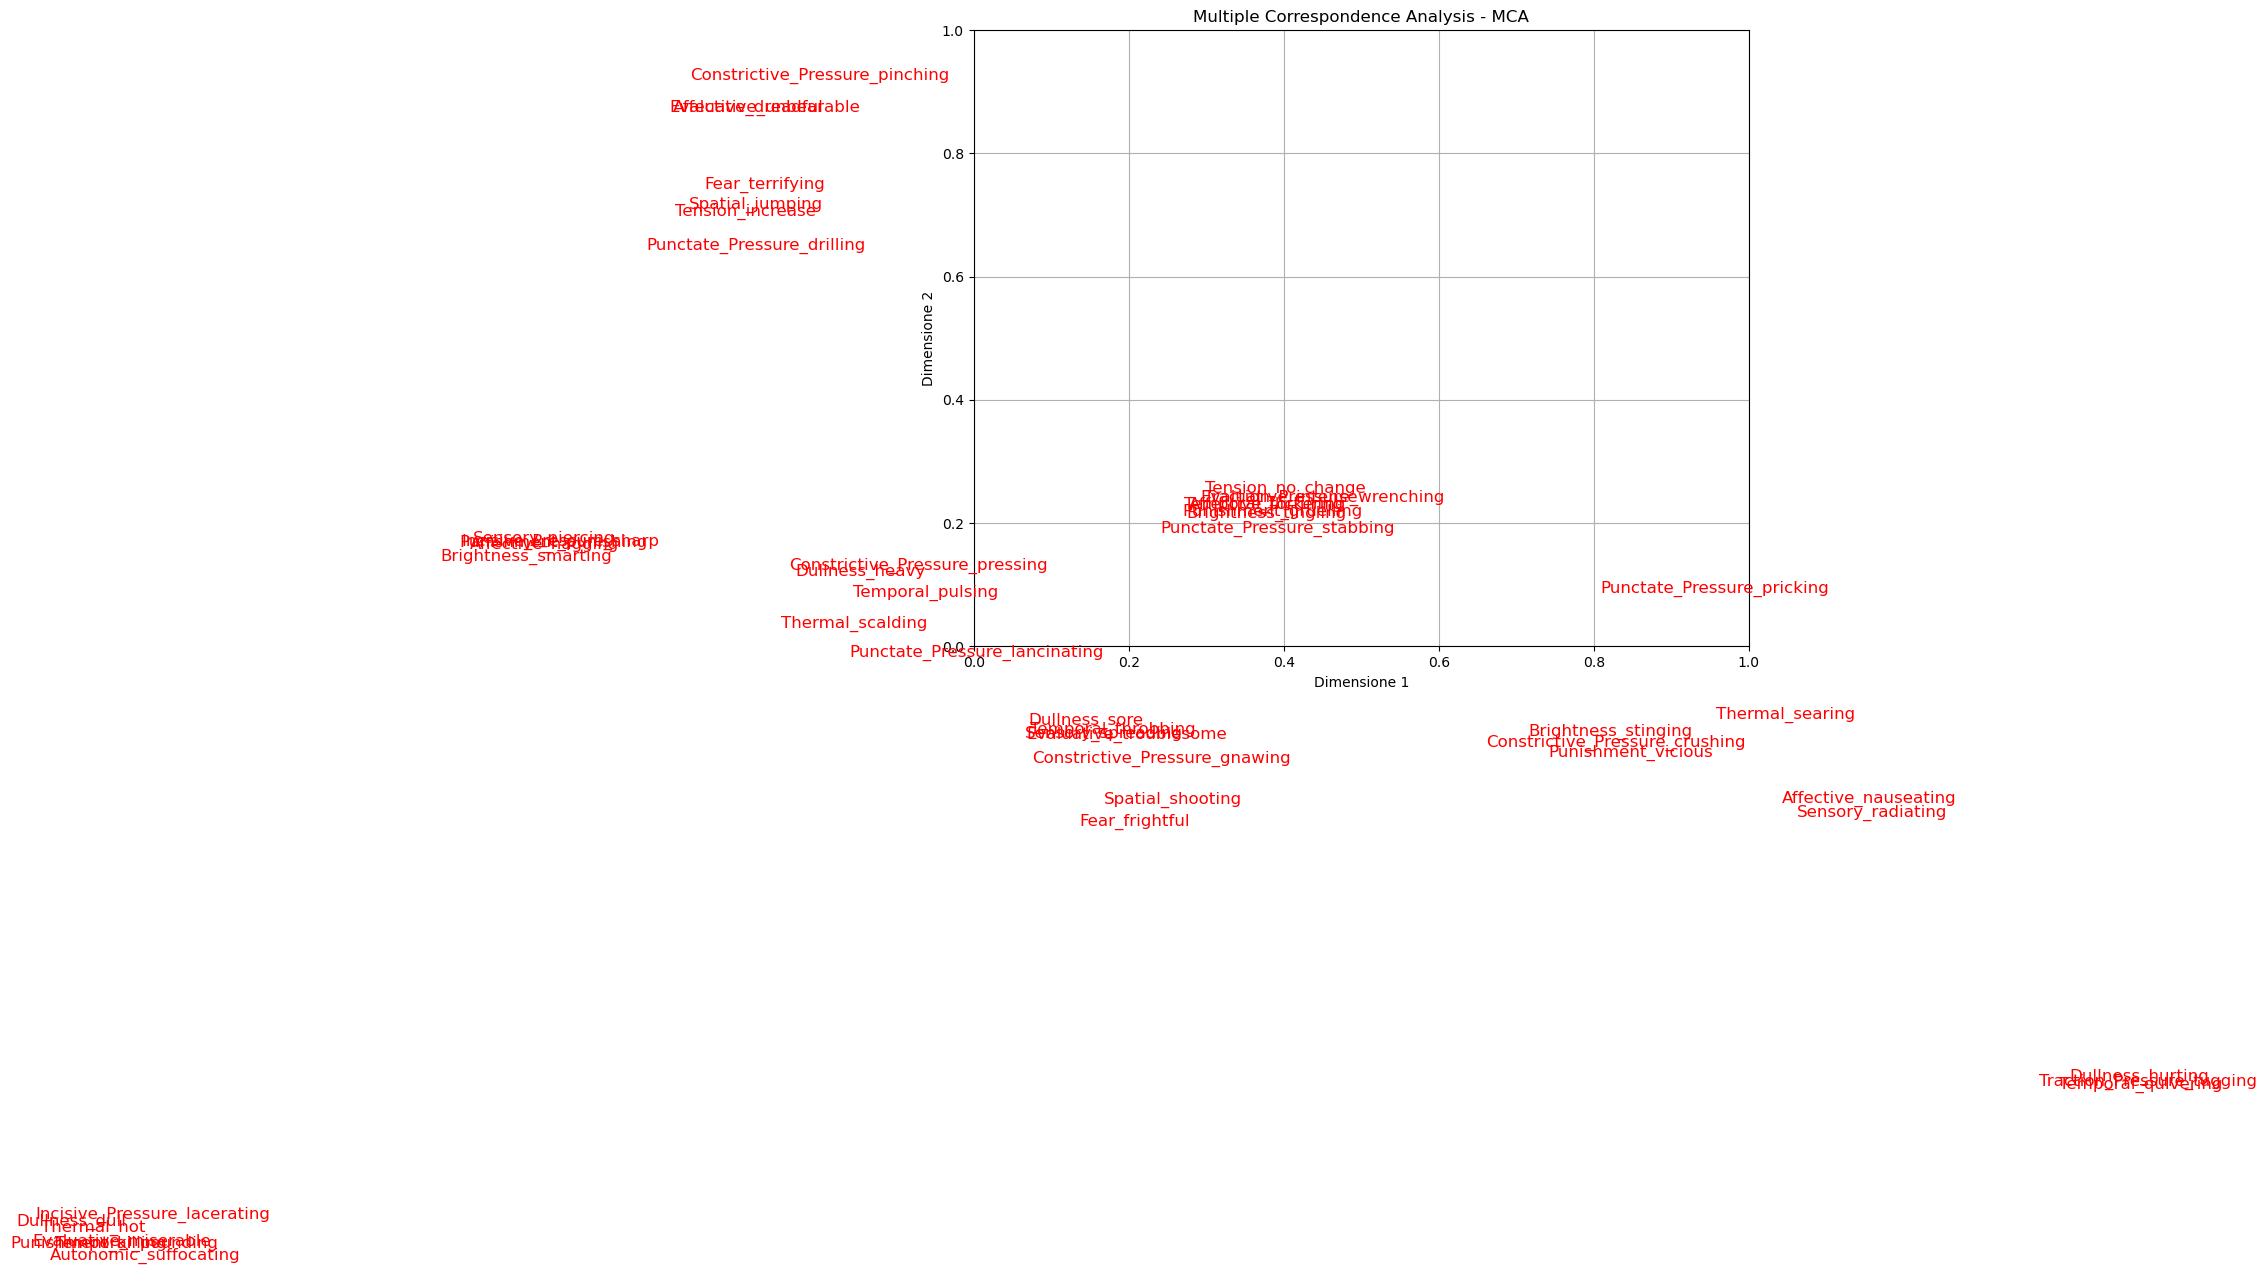

In [ ]:
import prince
df_encoded = pd.get_dummies(df[[  'Temporal', 'Spatial',  'Punctate_Pressure',  'Incisive_Pressure',  'Constrictive_Pressure', 'Traction_Pressure',  'Thermal', 'Brightness',  'Dullness',   'Tension',  'Autonomic',  'Fear', 'Punishment',   'Evaluative',  'Sensory', 'Affective']], drop_first=True)  


mca = prince.MCA(n_components=15, engine='sklearn')
mca = mca.fit(df_encoded)
mca_coordinates = mca.transform(df_encoded)
print(mca_coordinates.head())
variables_coordinates = mca.column_coordinates(df_encoded)
plt.figure(figsize=(10, 8))
#plt.scatter(mca_coordinates[0], mca_coordinates[1], alpha=0.5, color='blue')
plt.title('Multiple Correspondence Analysis - MCA')
plt.xlabel('Dimensione 1')
plt.ylabel('Dimensione 2')
for i in range(min(variables_coordinates.shape[0], df_encoded.shape[1])):
    plt.text(variables_coordinates.iloc[i, 0], variables_coordinates.iloc[i, 1], 
             df_encoded.columns[i], color='red', fontsize=12)
plt.grid(True)
plt.show()

In [19]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.254,25.41%,25.41%
1,0.122,12.18%,37.59%
2,0.039,3.93%,41.51%
3,0.032,3.22%,44.73%
4,0.029,2.91%,47.64%
5,0.028,2.77%,50.41%
6,0.027,2.72%,53.13%
7,0.026,2.61%,55.74%
8,0.026,2.57%,58.32%


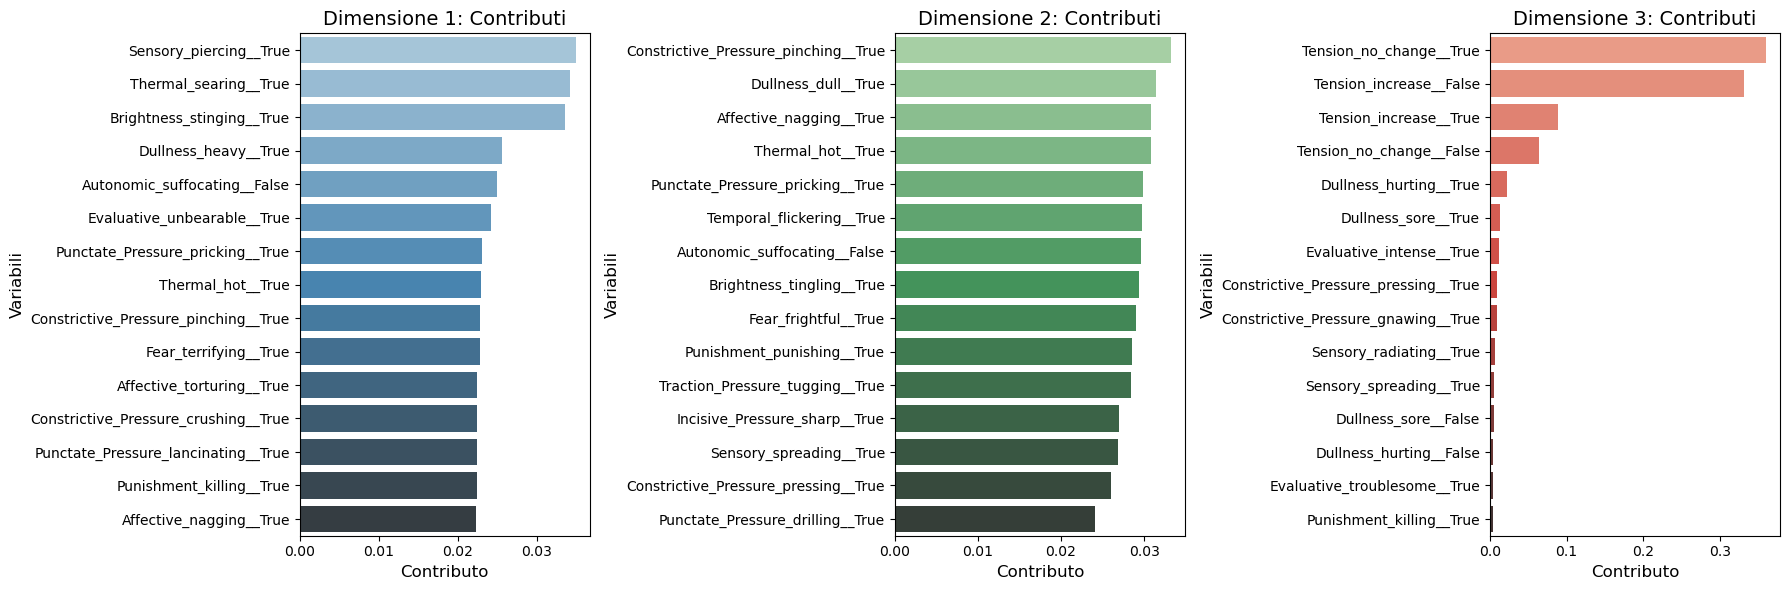

In [20]:
contributions = mca.column_contributions_

top_contributions = contributions.iloc[:, :3]

top_contributions_1 = top_contributions.iloc[:, 0].sort_values(ascending=False).head(15)
top_contributions_2 = top_contributions.iloc[:, 1].sort_values(ascending=False).head(15)
top_contributions_3 = top_contributions.iloc[:, 2].sort_values(ascending=False).head(15)

top_contributions_1 = contributions.iloc[:, 0].sort_values(ascending=False).head(15)
top_contributions_2 = contributions.iloc[:, 1].sort_values(ascending=False).head(15)
top_contributions_3 = contributions.iloc[:, 2].sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x=top_contributions_1.values, y=top_contributions_1.index, ax=axes[0], palette='Blues_d')
axes[0].set_title('Dimensione 1: Contributi', fontsize=14)
axes[0].set_xlabel('Contributo', fontsize=12)
axes[0].set_ylabel('Variabili', fontsize=12)

sns.barplot(x=top_contributions_2.values, y=top_contributions_2.index, ax=axes[1], palette='Greens_d')
axes[1].set_title('Dimensione 2: Contributi', fontsize=14)
axes[1].set_xlabel('Contributo', fontsize=12)
axes[1].set_ylabel('Variabili', fontsize=12)

sns.barplot(x=top_contributions_3.values, y=top_contributions_3.index, ax=axes[2], palette='Reds_d')
axes[2].set_title('Dimensione 3: Contributi', fontsize=14)
axes[2].set_xlabel('Contributo', fontsize=12)
axes[2].set_ylabel('Variabili', fontsize=12)

plt.tight_layout()
plt.show()